# 📈 Stock Price Prediction — 1 Year + Fundamental Analysis
Prediksi harga saham 252 hari ke depan menggabungkan **technical** + **fundamental** features.

**Fundamental Features (via yfinance):**
- Valuation: P/E, P/B, P/S, EV/EBITDA, PEG Ratio
- Profitability: ROE, ROA, ROIC, Gross/Operating/Net Margin
- Growth: Revenue YoY, EPS YoY, Quarterly EPS
- Financial Health: Debt/Equity, Current Ratio, Quick Ratio, Interest Coverage
- Cash Flow: FCF Yield, FCF/Share, CapEx ratio
- Earnings Events: Days to/from earnings, EPS surprise, post-earnings drift

> ⚠️ **Disclaimer**: Hanya untuk keperluan edukatif — bukan saran keuangan.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression, HuberRegressor, QuantileRegressor, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb

plt.style.use('seaborn-v0_8-darkgrid')
print('✓ Libraries loaded')


✓ Libraries loaded


In [2]:
TICKER   = 'MU'
PERIOD   = '5y'
INTERVAL = '1d'

# ── Harga utama ────────────────────────────────────────────────────────────────
df = yf.download(TICKER, period=PERIOD, interval=INTERVAL)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

# ── Makro: SPY & VIX ──────────────────────────────────────────────────────────
spy = yf.download('SPY', period=PERIOD, interval=INTERVAL)[['Close']]
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = [col[0] for col in spy.columns]
spy.columns = ['SPY_Close']

vix = yf.download('^VIX', period=PERIOD, interval=INTERVAL)[['Close']]
if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = [col[0] for col in vix.columns]
vix.columns = ['VIX']

df = df.join(spy, how='left').join(vix, how='left')
df['SPY_Close'] = df['SPY_Close'].ffill()
df['VIX']       = df['VIX'].ffill()

print(f'{TICKER}: {len(df)} days ({df.index[0].date()} — {df.index[-1].date()})')
print(f'Current Price : ${float(df["Close"].iloc[-1]):.2f}')
print(f'VIX           : {float(df["VIX"].iloc[-1]):.2f}')


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


MU: 1255 days (2021-05-13 — 2026-05-12)
Current Price : $766.58
VIX           : 17.99


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Download semua data fundamental dari yfinance
# ─────────────────────────────────────────────────────────────────────────────
ticker_obj = yf.Ticker(TICKER)

# ── Static fundamentals (dari info) ──────────────────────────────────────────
info = ticker_obj.info

STATIC_KEYS = [
    # Valuation
    'trailingPE', 'forwardPE', 'priceToBook', 'priceToSalesTrailing12Months',
    'enterpriseToEbitda', 'enterpriseToRevenue', 'pegRatio',
    # Profitability
    'returnOnEquity', 'returnOnAssets', 'grossMargins',
    'operatingMargins', 'profitMargins', 'ebitdaMargins',
    # Growth
    'revenueGrowth', 'earningsGrowth', 'earningsQuarterlyGrowth',
    'revenuePerShare', 'trailingEps', 'forwardEps',
    # Financial Health
    'debtToEquity', 'currentRatio', 'quickRatio',
    'totalDebt', 'totalCash', 'totalCashPerShare',
    # Cash Flow
    'freeCashflow', 'operatingCashflow',
    # Dividend
    'dividendYield', 'payoutRatio',
    # Short Interest
    'shortRatio', 'shortPercentOfFloat',
    # Shares
    'sharesOutstanding', 'floatShares', 'heldPercentInstitutions', 'heldPercentInsiders',
    # Beta
    'beta',
]

static_fund = {k: info.get(k, np.nan) for k in STATIC_KEYS}
print('Static fundamentals loaded:')
for k, v in static_fund.items():
    if v is not None and not (isinstance(v, float) and np.isnan(v)):
        print(f'  {k:<40s}: {v}')


Static fundamentals loaded:
  trailingPE                              : 36.22779
  forwardPE                               : 7.53158
  priceToBook                             : 11.933621
  priceToSalesTrailing12Months            : 14.874625
  enterpriseToEbitda                      : 23.387
  enterpriseToRevenue                     : 14.809
  pegRatio                                : 0.26
  returnOnEquity                          : 0.39823002
  returnOnAssets                          : 0.20145
  grossMargins                            : 0.58437
  operatingMargins                        : 0.67624
  profitMargins                           : 0.41486
  ebitdaMargins                           : 0.63324
  revenueGrowth                           : 1.963
  earningsGrowth                          : 7.56
  earningsQuarterlyGrowth                 : 7.708
  revenuePerShare                         : 51.799
  trailingEps                             : 21.16
  forwardEps                              :

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Quarterly time-series fundamentals
# ─────────────────────────────────────────────────────────────────────────────

def safe_get(obj, attr):
    try: return getattr(obj, attr)
    except: return pd.DataFrame()

# Income Statement
q_income = safe_get(ticker_obj, 'quarterly_income_stmt')
# Balance Sheet
q_balance = safe_get(ticker_obj, 'quarterly_balance_sheet')
# Cash Flow
q_cashflow = safe_get(ticker_obj, 'quarterly_cash_flow')
# Earnings history
q_earnings = safe_get(ticker_obj, 'earnings_dates')

print('Quarterly data shape:')
print(f'  Income stmt : {q_income.shape}')
print(f'  Balance sheet: {q_balance.shape}')
print(f'  Cash flow   : {q_cashflow.shape}')
print(f'  Earnings dates: {len(q_earnings) if not q_earnings.empty else 0} rows')

# ── Build quarterly fundamental time-series ───────────────────────────────────
def extract_row(df, label):
    """Ambil satu baris dari quarterly dataframe, transpose ke series."""
    if df.empty or label not in df.index:
        return pd.Series(dtype=float)
    s = df.loc[label].dropna()
    s.index = pd.to_datetime(s.index)
    return s.sort_index().astype(float)

# Income
revenue      = extract_row(q_income, 'Total Revenue')
gross_profit = extract_row(q_income, 'Gross Profit')
net_income   = extract_row(q_income, 'Net Income')
ebitda       = extract_row(q_income, 'EBITDA')
eps_basic    = extract_row(q_income, 'Basic EPS')
eps_diluted  = extract_row(q_income, 'Diluted EPS')

# Balance
total_assets = extract_row(q_balance, 'Total Assets')
total_equity = extract_row(q_balance, 'Stockholders Equity')
total_debt_q = extract_row(q_balance, 'Total Debt')
cash_q       = extract_row(q_balance, 'Cash And Cash Equivalents')

# Cash Flow
op_cf  = extract_row(q_cashflow, 'Operating Cash Flow')
capex  = extract_row(q_cashflow, 'Capital Expenditure')
fcf_q  = op_cf - capex.abs()  # Free Cash Flow

# Computed ratios per quarter
gross_margin_q = (gross_profit / revenue).rename('GrossMargin_Q')
net_margin_q   = (net_income   / revenue).rename('NetMargin_Q')
roe_q          = (net_income   / total_equity).rename('ROE_Q')
roa_q          = (net_income   / total_assets).rename('ROA_Q')
de_ratio_q     = (total_debt_q / total_equity).rename('DE_Ratio_Q')
revenue_yoy    = revenue.pct_change(4).rename('Revenue_YoY')    # QoQ 4 quarters back = YoY
eps_yoy        = eps_diluted.pct_change(4).rename('EPS_YoY')
eps_qoq        = eps_diluted.pct_change(1).rename('EPS_QoQ')
fcf_margin_q   = (fcf_q / revenue).rename('FCF_Margin_Q')

# Gabung jadi satu DataFrame quarterly
fund_q = pd.concat([
    revenue.rename('Revenue_Q'),
    eps_diluted.rename('EPS_Diluted_Q'),
    gross_margin_q, net_margin_q, roe_q, roa_q, de_ratio_q,
    revenue_yoy, eps_yoy, eps_qoq, fcf_margin_q,
    fcf_q.rename('FCF_Q'),
    ebitda.rename('EBITDA_Q'),
], axis=1)

fund_q = fund_q.sort_index()
print(f'\nQuarterly fundamental table: {fund_q.shape}')
print(fund_q.tail(6).to_string())


Quarterly data shape:
  Income stmt : (47, 6)
  Balance sheet: (77, 7)
  Cash flow   : (42, 7)
  Earnings dates: 25 rows

Quarterly fundamental table: (5, 13)
               Revenue_Q  EPS_Diluted_Q  GrossMargin_Q  NetMargin_Q     ROE_Q     ROA_Q  DE_Ratio_Q  Revenue_YoY   EPS_YoY   EPS_QoQ  FCF_Margin_Q         FCF_Q      EBITDA_Q
2025-02-28  8.053000e+09           1.41       0.367937     0.196573  0.032550  0.021669    0.307487          NaN       NaN       NaN     -0.014032 -1.130000e+08  3.949000e+09
2025-05-31  9.301000e+09           1.68       0.377164     0.202666  0.037144  0.024044    0.318062          NaN       NaN  0.191489      0.179658  1.671000e+09  4.330000e+09
2025-08-31  1.131500e+10           2.83       0.446664     0.282899  0.059097  0.038660    0.282064          NaN       NaN  0.684524      0.006363  7.200000e+07  5.904000e+09
2025-11-30  1.364300e+10           4.60       0.560434     0.384080  0.089107  0.060951    0.211288          NaN       NaN  0.625442      0.2

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Earnings Event Window Features
# - Berapa hari sebelum earnings berikutnya
# - Berapa hari sejak earnings terakhir
# - EPS Surprise (Actual vs Estimated)
# - Post-earnings drift: return 1/3/5 hari setelah earnings
# ─────────────────────────────────────────────────────────────────────────────

# Ambil earnings dates
earn_df = ticker_obj.earnings_dates
if earn_df is not None and not earn_df.empty:
    earn_df = earn_df.copy()
    earn_df.index = pd.to_datetime(earn_df.index).tz_localize(None)
    earn_df = earn_df.sort_index()

    # Kolom EPS
    eps_act_col  = [c for c in earn_df.columns if 'Reported' in c or 'Actual' in c]
    eps_est_col  = [c for c in earn_df.columns if 'Estimated' in c or 'Estimate' in c]
    eps_act_col  = eps_act_col[0]  if eps_act_col  else None
    eps_est_col  = eps_est_col[0]  if eps_est_col  else None

    if eps_act_col and eps_est_col:
        earn_df['EPS_Surprise_Abs'] = earn_df[eps_act_col] - earn_df[eps_est_col]
        earn_df['EPS_Surprise_Pct'] = earn_df['EPS_Surprise_Abs'] / earn_df[eps_est_col].abs()
    else:
        earn_df['EPS_Surprise_Abs'] = np.nan
        earn_df['EPS_Surprise_Pct'] = np.nan

    # Tanggal earnings yang sudah lewat
    past_earnings = earn_df[earn_df.index <= pd.Timestamp.today()].index
    future_earnings = earn_df[earn_df.index > pd.Timestamp.today()].index

    print(f'Total earnings dates : {len(earn_df)}')
    print(f'Past earnings        : {len(past_earnings)}')
    print(f'Future earnings      : {len(future_earnings)}')
    if len(future_earnings) > 0:
        print(f'Next earnings date   : {future_earnings[0].date()}')
    print('\nLast 4 earnings:')
    print(earn_df.tail(4)[['EPS_Surprise_Abs', 'EPS_Surprise_Pct']].to_string())
else:
    print('Earnings dates tidak tersedia untuk ticker ini.')
    earn_df = pd.DataFrame()
    past_earnings = []


Total earnings dates : 25
Past earnings        : 24
Future earnings      : 1
Next earnings date   : 2026-06-24

Last 4 earnings:
                     EPS_Surprise_Abs  EPS_Surprise_Pct
Earnings Date                                          
2025-09-23 16:00:00              0.17          0.059441
2025-12-17 16:00:00              0.82          0.207071
2026-03-18 16:00:00              3.04          0.331878
2026-06-24 16:00:00               NaN               NaN


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Peta semua fundamental ke index harian dengan forward-fill
# dan tambahkan event window features
# ─────────────────────────────────────────────────────────────────────────────

daily_index = df.index  # DatetimeIndex harian

# ── 1. Forward-fill quarterly fundamentals ke harian ─────────────────────────
fund_daily = fund_q.reindex(daily_index, method='ffill')

# ── 2. Static fundamentals → broadcast ke semua hari ─────────────────────────
for k, v in static_fund.items():
    val = v if (v is not None and not (isinstance(v, float) and np.isnan(v) if isinstance(v, float) else False)) else np.nan
    fund_daily[k] = val

# ── 3. Earnings event window ──────────────────────────────────────────────────
fund_daily['Days_Since_Earnings'] = np.nan
fund_daily['Days_To_Earnings']    = np.nan
fund_daily['EPS_Surprise_Pct']    = np.nan
fund_daily['EPS_Surprise_Abs']    = np.nan
fund_daily['Post_Earn_Return_1d'] = np.nan
fund_daily['Post_Earn_Return_3d'] = np.nan
fund_daily['Post_Earn_Return_5d'] = np.nan
fund_daily['In_Earn_Window']      = 0   # 1 jika dalam 5 hari sebelum/sesudah earnings

if len(past_earnings) > 0:
    earn_dates_sorted = sorted(past_earnings)
    all_earn_ts = pd.DatetimeIndex(earn_dates_sorted)

    for date in daily_index:
        # Days since last earnings
        past = all_earn_ts[all_earn_ts <= date]
        if len(past) > 0:
            last_earn = past[-1]
            fund_daily.loc[date, 'Days_Since_Earnings'] = (date - last_earn).days

            # EPS surprise dari earnings terakhir
            if last_earn in earn_df.index:
                fund_daily.loc[date, 'EPS_Surprise_Pct'] = earn_df.loc[last_earn, 'EPS_Surprise_Pct']
                fund_daily.loc[date, 'EPS_Surprise_Abs'] = earn_df.loc[last_earn, 'EPS_Surprise_Abs']

            # Post-earnings return (drift setelah earnings)
            earn_idx = df.index.searchsorted(last_earn)
            if earn_idx < len(df) - 5:
                p0 = float(df['Close'].iloc[earn_idx])
                fund_daily.loc[date, 'Post_Earn_Return_1d'] = float(df['Close'].iloc[min(earn_idx+1, len(df)-1)]) / p0 - 1
                fund_daily.loc[date, 'Post_Earn_Return_3d'] = float(df['Close'].iloc[min(earn_idx+3, len(df)-1)]) / p0 - 1
                fund_daily.loc[date, 'Post_Earn_Return_5d'] = float(df['Close'].iloc[min(earn_idx+5, len(df)-1)]) / p0 - 1

        # Days to next earnings
        future_e = all_earn_ts[all_earn_ts > date]
        if len(future_e) > 0:
            fund_daily.loc[date, 'Days_To_Earnings'] = (future_e[0] - date).days

        # Earnings window flag (±5 hari)
        min_dist = min(
            abs((date - e).days) for e in earn_dates_sorted
            if abs((date - e).days) <= 5
        ) if any(abs((date - e).days) <= 5 for e in earn_dates_sorted) else 999
        fund_daily.loc[date, 'In_Earn_Window'] = 1 if min_dist <= 5 else 0

# Gabung ke df utama
df = df.join(fund_daily, how='left')

print(f'Fundamental features ditambahkan. Total kolom df: {df.shape[1]}')
print(f'Earnings window days: {df["In_Earn_Window"].sum():.0f} hari')


Fundamental features ditambahkan. Total kolom df: 64
Earnings window days: 137 hari


In [7]:
# ── Technical indicators ──────────────────────────────────────────────────────
df['SMA_10'] = ta.sma(df['Close'], length=10)
df['SMA_20'] = ta.sma(df['Close'], length=20)
df['SMA_50'] = ta.sma(df['Close'], length=50)
df['SMA_200']= ta.sma(df['Close'], length=200)
df['RSI']    = ta.rsi(df['Close'], length=14)

macd = ta.macd(df['Close'])
df['MACD']        = macd.iloc[:, 0]
df['MACD_Signal'] = macd.iloc[:, 1]
df['MACD_Hist']   = macd.iloc[:, 2]

bb = ta.bbands(df['Close'], length=20, std=2)
df['BB_Upper'] = bb.iloc[:, 2]
df['BB_Lower'] = bb.iloc[:, 0]
df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['SMA_20']

adx = ta.adx(df['High'], df['Low'], df['Close'], length=14)
df['ADX'] = adx.iloc[:, 0]
df['DMP'] = adx.iloc[:, 1]
df['DMN'] = adx.iloc[:, 2]

df['Volume_SMA']   = ta.sma(df['Volume'], length=20)
df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA']
df['ATR']          = ta.atr(df['High'], df['Low'], df['Close'], length=14)
df['MFI']          = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)

# Lag features
for lag in range(1, 6):
    df[f'Close_lag{lag}']  = df['Close'].shift(lag)
    df[f'Volume_lag{lag}'] = df['Volume'].shift(lag)

# Rolling features
ret = df['Close'].pct_change()
df['Close_roc_5']   = df['Close'].pct_change(5)
df['Close_roc_21']  = df['Close'].pct_change(21)
df['Close_roc_63']  = df['Close'].pct_change(63)
df['Volatility_10'] = ret.rolling(10).std()
df['Volatility_21'] = ret.rolling(21).std()
df['Skew_20']       = ret.rolling(20).skew()
df['Kurt_20']       = ret.rolling(20).kurt()

# Makro relative
df['SPY_Return_21']  = df['SPY_Close'].pct_change(21)
df['Relative_SPY']   = df['Close'] / df['SPY_Close']
df['Rel_SPY_roc_21'] = df['Relative_SPY'].pct_change(21)
df['VIX_lag1']       = df['VIX'].shift(1)
df['VIX_Change']     = df['VIX'].pct_change()

# Calendar
df['DayOfWeek']  = df.index.dayofweek
df['Month']      = df.index.month
df['QuarterEnd'] = df.index.is_quarter_end.astype(int)

# Direct multi-step targets: beberapa horizon penting
for h in [1, 5, 21, 63, 126, 252]:
    df[f'Target_Return_D{h}'] = df['Close'].pct_change().shift(-h)

print(f'Technical features selesai. Shape: {df.shape}')


Technical features selesai. Shape: (1255, 113)


In [8]:
# ── Technical features ────────────────────────────────────────────────────────
TECH_FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Width',
    'ADX', 'DMP', 'DMN', 'MFI',
    'Volume_Ratio', 'ATR',
    'Close_lag1', 'Close_lag2', 'Close_lag3', 'Close_lag4', 'Close_lag5',
    'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 'Volume_lag4', 'Volume_lag5',
    'Close_roc_5', 'Close_roc_21', 'Close_roc_63',
    'Volatility_10', 'Volatility_21', 'Skew_20', 'Kurt_20',
    'SPY_Return_21', 'Relative_SPY', 'Rel_SPY_roc_21',
    'VIX_lag1', 'VIX_Change',
    'DayOfWeek', 'Month', 'QuarterEnd',
]

# ── Fundamental features ──────────────────────────────────────────────────────
FUND_FEATURES = [
    # Quarterly time-series
    'Revenue_Q', 'EPS_Diluted_Q', 'EBITDA_Q', 'FCF_Q',
    'GrossMargin_Q', 'NetMargin_Q', 'FCF_Margin_Q',
    'ROE_Q', 'ROA_Q', 'DE_Ratio_Q',
    'Revenue_YoY', 'EPS_YoY', 'EPS_QoQ',
    # Static (broadcast)
    'trailingPE', 'forwardPE', 'priceToBook', 'priceToSalesTrailing12Months',
    'enterpriseToEbitda', 'pegRatio',
    'returnOnEquity', 'returnOnAssets', 'grossMargins', 'operatingMargins', 'profitMargins',
    'revenueGrowth', 'earningsGrowth',
    'debtToEquity', 'currentRatio', 'quickRatio',
    'shortRatio', 'beta',
    'heldPercentInstitutions', 'heldPercentInsiders',
    # Earnings event window
    'Days_Since_Earnings', 'Days_To_Earnings',
    'EPS_Surprise_Pct', 'EPS_Surprise_Abs',
    'Post_Earn_Return_1d', 'Post_Earn_Return_3d', 'Post_Earn_Return_5d',
    'In_Earn_Window',
]

# Hanya pakai kolom yang benar-benar ada di df
FUND_FEATURES = [f for f in FUND_FEATURES if f in df.columns]
FEATURES      = TECH_FEATURES + FUND_FEATURES

TARGETS = [f'Target_Return_D{h}' for h in [1, 5, 21, 63, 126, 252]]

# ── Guard: pastikan df tidak kosong ──────────────────────────────────────
assert len(df) > 0, 'df kosong — jalankan ulang sel download data di atas'
assert 'Close' in df.columns, 'Kolom Close tidak ditemukan di df'

# Forward-fill lalu backward-fill (time-series safe) sebelum dropna
df_clean = df[FEATURES + TARGETS].copy()
df_clean = df_clean.ffill().bfill()

model_df = df_clean.dropna(subset=TECH_FEATURES + TARGETS).copy()

# Fundamental boleh masih ada NaN — isi dengan median kolom
for col in FUND_FEATURES:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(model_df[col].median())

# Final safety: isi sisa NaN apapun dengan median
for col in model_df.columns:
    if model_df[col].isna().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

assert len(model_df) > 0, f'model_df masih kosong setelah cleaning. Cek kolom: {[c for c in TECH_FEATURES if df[c].isna().all()]}'

split_idx = int(len(model_df) * 0.8)
train_df  = model_df.iloc[:split_idx]
test_df   = model_df.iloc[split_idx:]

print(f'Total features : {len(FEATURES)}')
print(f'  Technical    : {len(TECH_FEATURES)}')
print(f'  Fundamental  : {len(FUND_FEATURES)}')
print(f'Total rows     : {len(model_df)}')
print(f'Train          : {len(train_df)} | Test: {len(test_df)}')
print(f'Test period    : {test_df.index[0].date()} — {test_df.index[-1].date()}')


Total features : 88
  Technical    : 47
  Fundamental  : 41
Total rows     : 1255
Train          : 1004 | Test: 251
Test period    : 2025-05-13 — 2026-05-12


In [9]:
# model_df sudah bersih dari Cell 8 — tidak perlu dropna lagi
# Ambil hanya baris yang target D1-nya valid
wf_df  = model_df[model_df['Target_Return_D1'].notna()].copy()
X_all  = wf_df[FEATURES].values
y_d1   = wf_df['Target_Return_D1'].values
BASE_MODELS_DEF = [
    ('LinearReg',  LinearRegression()),
    ('RF',         RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, random_state=42, n_jobs=-1)),
    ('GBM',        GradientBoostingRegressor(n_estimators=200, learning_rate=0.03, max_depth=2, random_state=42)),
    ('SVR',        SVR(kernel='rbf', C=10, gamma='scale')),
    ('Huber',      HuberRegressor(epsilon=1.35, max_iter=300)),
    ('XGBoost',    xgb.XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=3,
                                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)),
    ('LightGBM',   lgb.LGBMRegressor(n_estimators=200, learning_rate=0.03, max_depth=3,
                                      subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)),
]
tscv = TimeSeriesSplit(n_splits=5)
wf_results = {}
print('Walk-Forward CV (5 splits, Day+1 return):')
print(f'{"Model":<12}' + ''.join(f' {"Fold"+str(i):>8}' for i in range(1,6)) + f' {"Mean":>8}')
print('-' * 60)
import copy
for name, model in BASE_MODELS_DEF:
    fold_maes = []
    for tr_idx, val_idx in tscv.split(X_all):
        Xtr, Xval = X_all[tr_idx], X_all[val_idx]
        ytr, yval = y_d1[tr_idx],  y_d1[val_idx]
        sc = StandardScaler()
        Xtr_sc  = sc.fit_transform(Xtr)
        Xval_sc = sc.transform(Xval)
        m = copy.deepcopy(model)
        if name == 'SVR':
            m.fit(Xtr_sc, ytr)
            preds = m.predict(Xval_sc)
        else:
            m.fit(Xtr, ytr)
            preds = m.predict(Xval)
        fold_maes.append(mean_absolute_error(yval, preds))
    wf_results[name] = fold_maes
    row = f'{name:<12}' + ''.join(f' {mae:>8.4f}' for mae in fold_maes) + f' {np.mean(fold_maes):>8.4f}'
    print(row)

Walk-Forward CV (5 splits, Day+1 return):
Model           Fold1    Fold2    Fold3    Fold4    Fold5     Mean
------------------------------------------------------------
LinearReg      0.6925   0.1344   0.0332   0.0358 10477.5871 2095.6966
RF             0.0231   0.0170   0.0229   0.0285   0.0357   0.0254
GBM            0.0235   0.0173   0.0287   0.0288   0.0620   0.0321
SVR            0.0248   0.0203   0.0235   0.0339   0.0329   0.0271
Huber          0.0228   0.0170   0.0214   0.0284   0.0335   0.0246
XGBoost        0.0238   0.0184   0.0252   0.0292   0.0482   0.0290
LightGBM       0.0239   0.0183   0.0239   0.0287   0.0398   0.0269


In [10]:
# ── Direct Multi-Step Training (1, 5, 21, 63, 126, 252 hari) ─────────────────
HORIZONS = [1, 5, 21, 63, 126, 252]

from sklearn.impute import SimpleImputer

X_train_raw = train_df[FEATURES].values
X_test_raw  = test_df[FEATURES].values

# Impute sisa NaN dengan median (fit pada train saja — cegah data leakage)
imputer    = SimpleImputer(strategy='median')
X_train    = imputer.fit_transform(X_train_raw)
X_test     = imputer.transform(X_test_raw)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

trained    = {}
test_preds = {}

for h in HORIZONS:
    tgt = f'Target_Return_D{h}'
    if tgt not in train_df.columns: continue
    y_tr = train_df[tgt].values
    y_te = test_df[tgt].values
    trained[h]    = {}
    test_preds[h] = {}

    for name, model in BASE_MODELS_DEF:
        m = copy.deepcopy(model)
        if name == 'SVR':
            m.fit(X_train_sc, y_tr)
            test_preds[h][name] = m.predict(X_test_sc)
        else:
            m.fit(X_train, y_tr)
            test_preds[h][name] = m.predict(X_test)
        trained[h][name] = m

print('Training selesai. Evaluasi per horizon:')
print(f'{"Horizon":<10} {"Model":<12} {"MAE":>8} {"Dir.Acc":>9}')
print('-' * 44)
for h in HORIZONS:
    if h not in trained: continue
    y_te = test_df[f'Target_Return_D{h}'].values
    for name in trained[h]:
        mae     = mean_absolute_error(y_te, test_preds[h][name])
        dir_acc = np.mean(np.sign(test_preds[h][name]) == np.sign(y_te)) * 100
        print(f'D+{h:<8} {name:<12} {mae:>8.4f} {dir_acc:>8.1f}%')
    print()


Training selesai. Evaluasi per horizon:
Horizon    Model             MAE   Dir.Acc
--------------------------------------------
D+1        LinearReg      0.1056     47.4%
D+1        RF             0.0323     45.4%
D+1        GBM            0.0518     48.6%
D+1        SVR            0.0303     58.6%
D+1        Huber          0.0304     52.2%
D+1        XGBoost        0.0420     45.4%
D+1        LightGBM       0.0351     45.8%

D+5        LinearReg      0.1036     48.6%
D+5        RF             0.0318     48.2%
D+5        GBM            0.0440     45.8%
D+5        SVR            0.0357     44.6%
D+5        Huber          0.0309     47.8%
D+5        XGBoost        0.0327     48.2%
D+5        LightGBM       0.0324     49.8%

D+21       LinearReg      0.0526     49.4%
D+21       RF             0.0324     53.0%
D+21       GBM            0.0401     49.4%
D+21       SVR            0.0343     53.0%
D+21       Huber          0.0322     52.6%
D+21       XGBoost        0.0339     48.2%
D+21      

In [11]:
# ── Stacking & Quantile per horizon ──────────────────────────────────────────
stacked_test  = {}
q10_test      = {}
q90_test      = {}
stacked_models = {}

for h in HORIZONS:
    if h not in trained: continue
    tgt  = f'Target_Return_D{h}'
    y_tr = train_df[tgt].values
    y_te = test_df[tgt].values

    # Stacking meta-model
    train_meta = np.column_stack([
        trained[h][n].predict(X_train_sc if n == 'SVR' else X_train)
        for n in trained[h]
    ])
    test_meta = np.column_stack([
        test_preds[h][n] for n in trained[h]
    ])
    meta = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
    meta.fit(train_meta, y_tr)
    stacked_test[h]   = meta.predict(test_meta)
    stacked_models[h] = meta

    # Quantile
    q10 = QuantileRegressor(quantile=0.10, alpha=0.1, solver='highs')
    q90 = QuantileRegressor(quantile=0.90, alpha=0.1, solver='highs')
    q10.fit(X_train, y_tr)
    q90.fit(X_train, y_tr)
    q10_test[h] = q10.predict(X_test)
    q90_test[h] = q90.predict(X_test)

print('Stacking & Quantile selesai.')
print(f'\n{"Horizon":<10} {"Stacked MAE":>12} {"Dir.Acc":>9}')
print('-' * 35)
for h in HORIZONS:
    if h not in stacked_test: continue
    y_te    = test_df[f'Target_Return_D{h}'].values
    mae     = mean_absolute_error(y_te, stacked_test[h])
    dir_acc = np.mean(np.sign(stacked_test[h]) == np.sign(y_te)) * 100
    print(f'D+{h:<8} {mae:>12.4f} {dir_acc:>8.1f}%')


Stacking & Quantile selesai.

Horizon     Stacked MAE   Dir.Acc
-----------------------------------
D+1              0.0494     46.2%
D+5              0.0403     52.6%
D+21             0.0374     50.6%
D+63             0.0379     54.6%
D+126            0.0331     61.0%
D+252            0.0793     17.1%


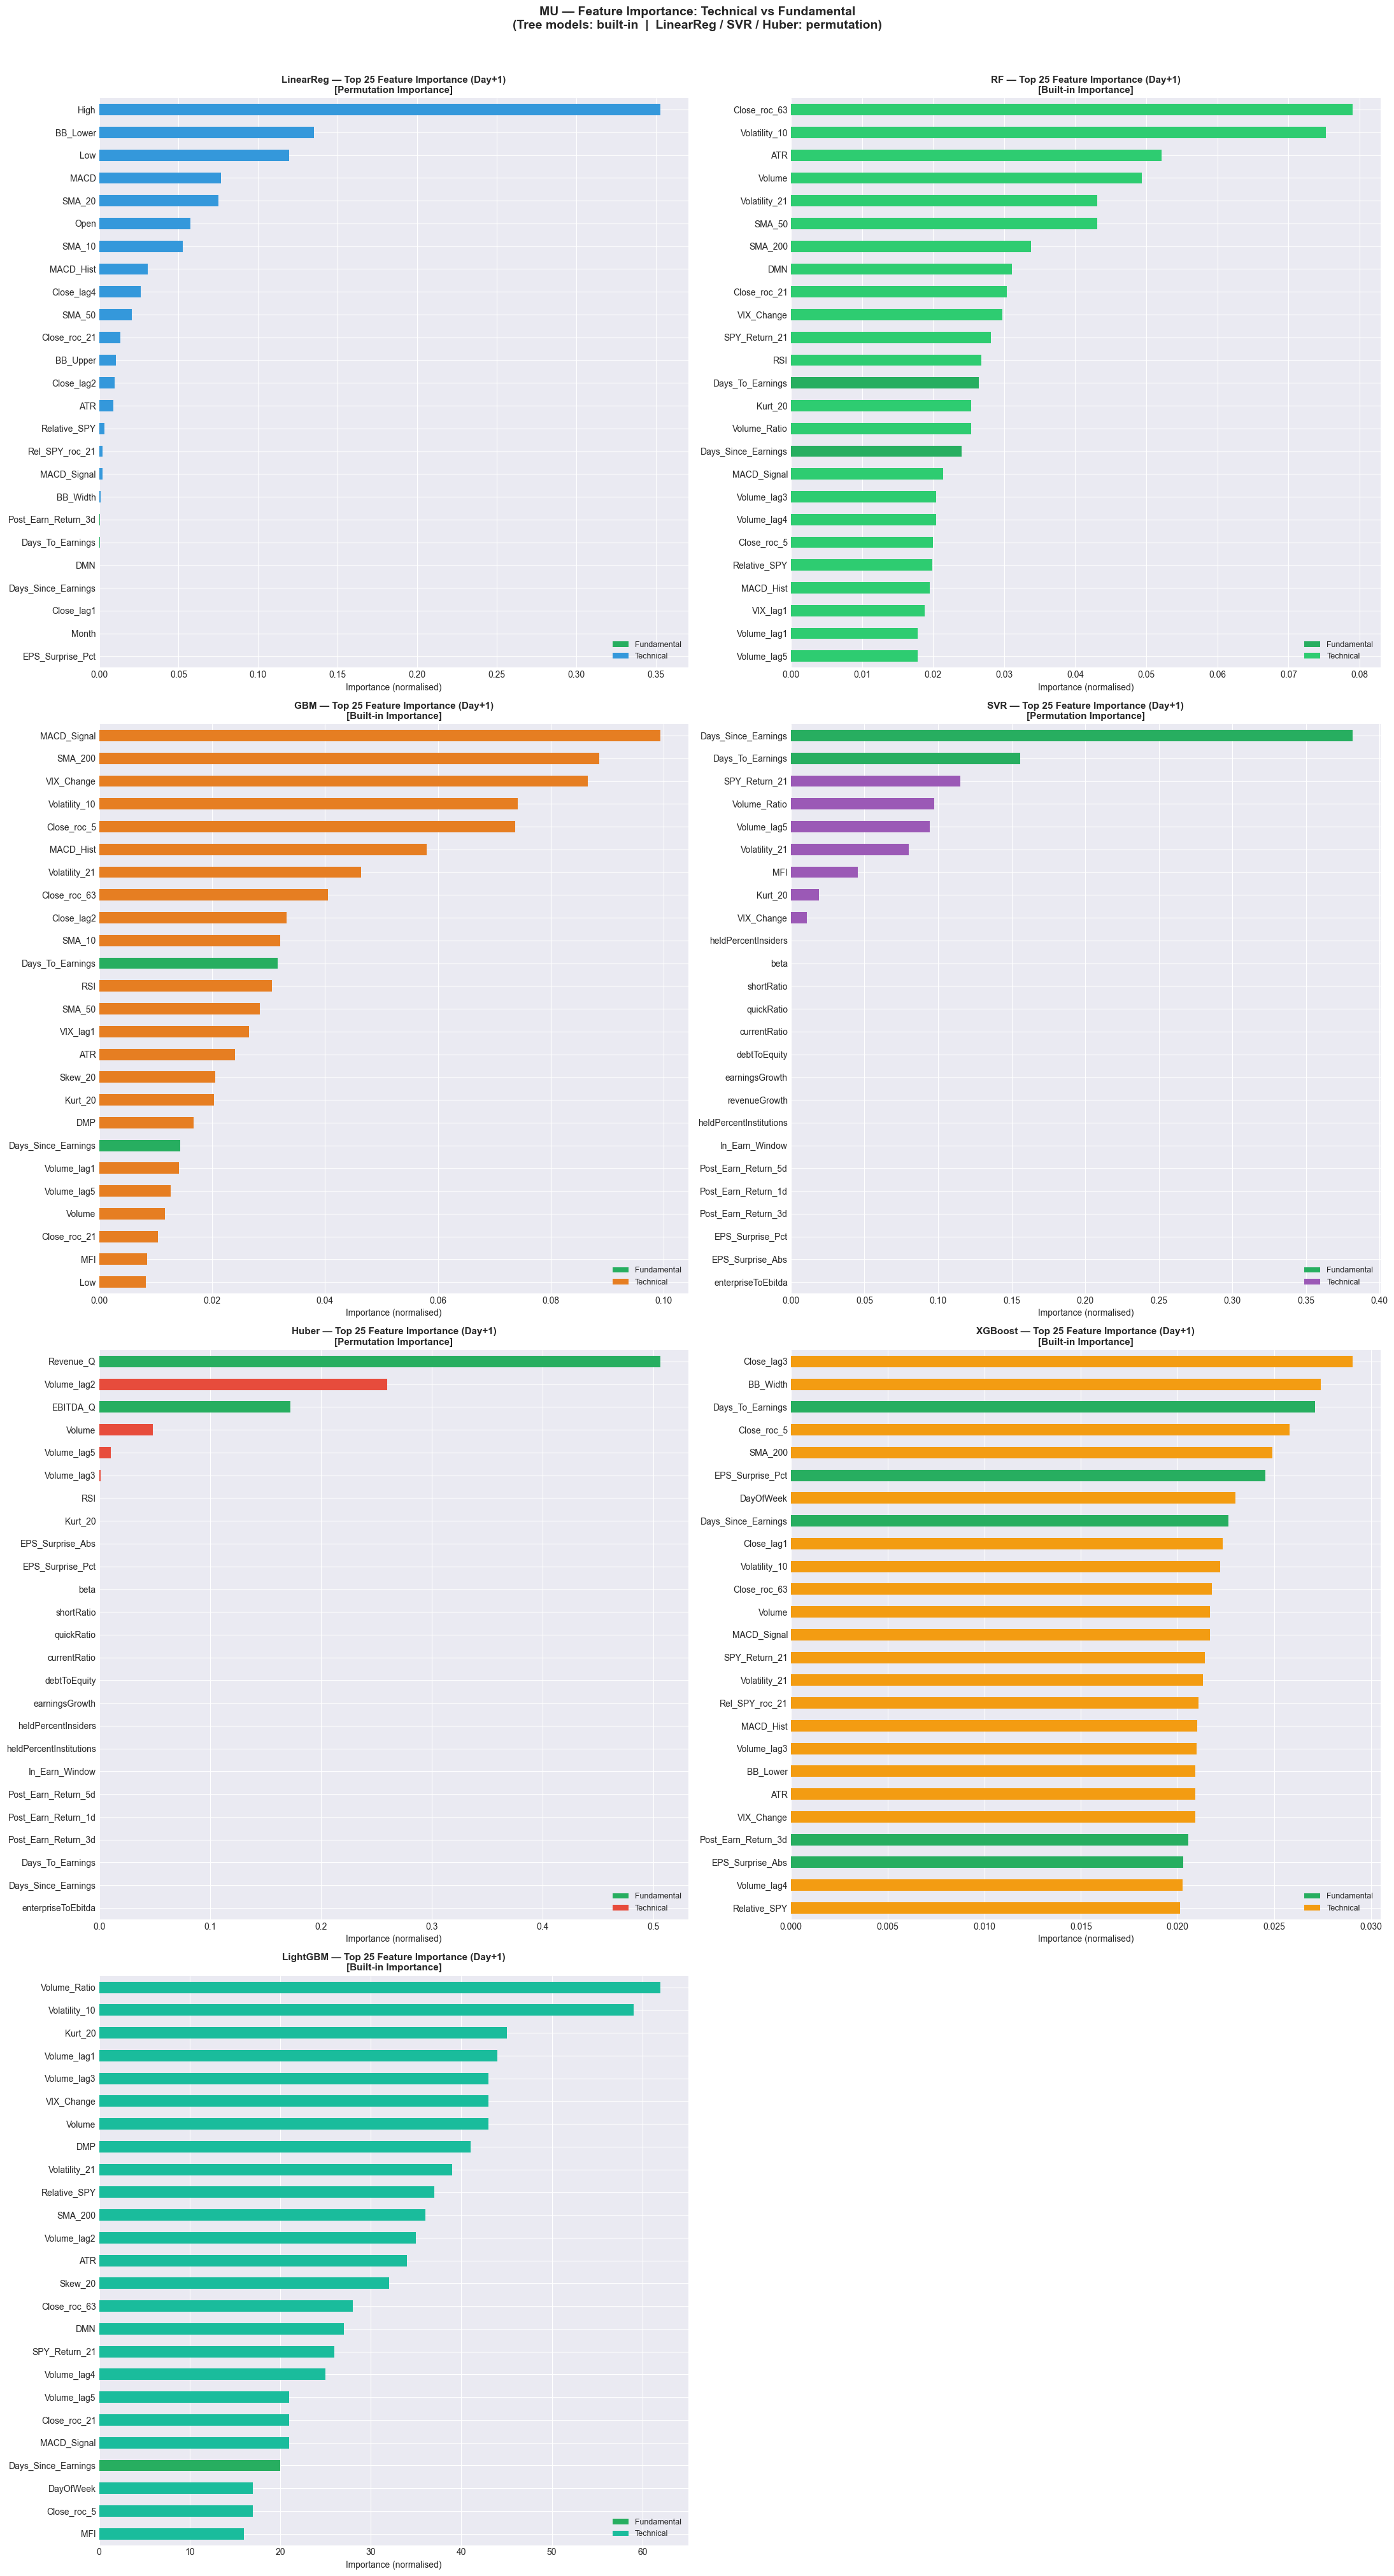


Model        Method                    Technical   Fundamental  Top-3 Features
──────────────────────────────────────────────────────────────────────────────────────────
LinearReg    Permutation Importance        99.8%           0.2%   High, BB_Lower, Low
RF           Built-in Importance           93.7%           6.3%   Close_roc_63, Volatility_10, ATR
GBM          Built-in Importance           95.4%           4.6%   MACD_Signal, SMA_200, VIX_Change
SVR          Permutation Importance        46.3%          53.7%   Days_Since_Earnings, Days_To_Earnings, SPY_Return_21
Huber        Permutation Importance        32.1%          67.9%   Revenue_Q, Volume_lag2, EBITDA_Q
XGBoost      Built-in Importance           85.1%          14.9%   Close_lag3, BB_Width, Days_To_Earnings
LightGBM     Built-in Importance        95500.0%        5700.0%   Volume_Ratio, Volatility_10, Kurt_20


In [17]:
import copy
from matplotlib.patches import Patch
from sklearn.inspection import permutation_importance

# ── Pisahkan model berdasarkan tipe importance ────────────────────────────────
TREE_MODELS  = {n: trained[1][n] for n in ['RF', 'GBM', 'XGBoost', 'LightGBM'] if n in trained[1]}
OTHER_MODELS = {n: trained[1][n] for n in ['LinearReg', 'SVR', 'Huber']         if n in trained[1]}

# Ambil data test untuk permutation importance
tgt_d1  = 'Target_Return_D1'
y_te_d1 = test_df[tgt_d1].values
X_te    = X_test      # sudah di-impute (dari Cell 10)
X_te_sc = X_test_sc   # sudah di-scale  (dari Cell 10)

# ── Hitung importance semua model ────────────────────────────────────────────
all_importances = {}

# Tree models → feature_importances_ (in-built, fast)
for name, m in TREE_MODELS.items():
    all_importances[name] = pd.Series(m.feature_importances_, index=FEATURES)

# Linear/SVR/Huber → permutation importance pada test set
for name, m in OTHER_MODELS.items():
    X_inp = X_te_sc if name == 'SVR' else X_te
    pi = permutation_importance(m, X_inp, y_te_d1,
                                n_repeats=15, random_state=42, n_jobs=-1)
    # Gunakan mean; clip negatif ke 0 (feature tidak berguna, bukan negatif)
    vals = np.clip(pi.importances_mean, 0, None)
    # Normalise supaya skala sama dengan tree models (sum=1)
    total = vals.sum()
    all_importances[name] = pd.Series(
        vals / total if total > 0 else vals, index=FEATURES
    )

# ── Plot: 7 subplots (4 baris × 2 kolom, subplot terakhir kosong) ─────────────
MODEL_ORDER = ['LinearReg', 'RF', 'GBM', 'SVR', 'Huber', 'XGBoost', 'LightGBM']
PALETTE     = {
    'LinearReg' : '#3498db',
    'RF'        : '#2ecc71',
    'GBM'       : '#e67e22',
    'SVR'       : '#9b59b6',
    'Huber'     : '#e74c3c',
    'XGBoost'   : '#f39c12',
    'LightGBM'  : '#1abc9c',
}
METHOD_LABEL = {n: 'Permutation Importance' for n in OTHER_MODELS}
METHOD_LABEL.update({n: 'Built-in Importance'   for n in TREE_MODELS})

cols  = 2
rows  = (len(MODEL_ORDER) + 1) // cols   # 4
fig, axes = plt.subplots(rows, cols, figsize=(22, 10 * rows))
axes = axes.flatten()

for ax, name in zip(axes, MODEL_ORDER):
    imp        = all_importances[name]
    top25      = imp.sort_values().tail(25)
    color      = PALETTE[name]
    colors_bar = ['#27ae60' if f in FUND_FEATURES else color for f in top25.index]

    top25.plot.barh(ax=ax, color=colors_bar)
    ax.set_title(
        f'{name} — Top 25 Feature Importance (Day+1)\n[{METHOD_LABEL[name]}]',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Importance (normalised)')
    ax.legend(handles=[
        Patch(facecolor='#27ae60', label='Fundamental'),
        Patch(facecolor=color,     label='Technical'),
    ], loc='lower right', fontsize=9)

# Sembunyikan subplot kosong (index ke-7, karena 7 model di grid 4×2)
for ax in axes[len(MODEL_ORDER):]:
    ax.set_visible(False)

plt.suptitle(
    f'{TICKER} — Feature Importance: Technical vs Fundamental\n'
    f'(Tree models: built-in  |  LinearReg / SVR / Huber: permutation)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ── Ringkasan tabel ───────────────────────────────────────────────────────────
print(f'\n{"Model":<12} {"Method":<24} {"Technical":>10} {"Fundamental":>13}  {"Top-3 Features"}')
print('─' * 90)
for name in MODEL_ORDER:
    imp      = all_importances[name]
    tech_pct = imp[TECH_FEATURES].sum() * 100
    fund_pct = imp[[f for f in FUND_FEATURES if f in FEATURES]].sum() * 100
    top3     = ', '.join(imp.sort_values(ascending=False).head(3).index.tolist())
    print(f'{name:<12} {METHOD_LABEL[name]:<24} {tech_pct:>9.1f}%  {fund_pct:>12.1f}%   {top3}')

In [13]:
# ── 1-Year Direct Prediction ──────────────────────────────────────────────────
last_date  = df.index[-1]
last_close = float(df['Close'].iloc[-1])

last_row    = model_df.iloc[-1:][FEATURES].values
last_row_sc = scaler.transform(last_row)

# Prediksi untuk semua horizon
results = {}
for h in HORIZONS:
    if h not in trained: continue
    model_preds = {}
    for name in trained[h]:
        r = trained[h][name].predict(last_row_sc if name == 'SVR' else last_row)[0]
        model_preds[name] = last_close * (1 + r)

    # Stacked
    base_outs = np.array([
        trained[h][n].predict(last_row_sc if n == 'SVR' else last_row)[0]
        for n in trained[h]
    ]).reshape(1, -1)
    r_stacked = stacked_models[h].predict(base_outs)[0]
    model_preds['Stacked'] = last_close * (1 + r_stacked)

    # Quantile bounds
    y_tr_h = train_df[f'Target_Return_D{h}'].values
    q10m = QuantileRegressor(quantile=0.10, alpha=0.1, solver='highs').fit(X_train, y_tr_h)
    q90m = QuantileRegressor(quantile=0.90, alpha=0.1, solver='highs').fit(X_train, y_tr_h)
    model_preds['Q10'] = last_close * (1 + q10m.predict(last_row)[0])
    model_preds['Q90'] = last_close * (1 + q90m.predict(last_row)[0])
    results[h] = model_preds

# ── Print ringkasan ───────────────────────────────────────────────────────────
print(f'1-Year Price Prediction for {TICKER}')
print(f'Last Close : ${last_close:.2f} ({last_date.date()})')
print('=' * 95)

horizon_labels = {1:'1 Day', 5:'1 Week', 21:'1 Month', 63:'3 Months', 126:'6 Months', 252:'1 Year'}
model_names    = list(trained[1].keys()) + ['Stacked']

header = f'{"Horizon":<12}'
for n in model_names:
    header += f' {n[:6]:>9}'
header += f' {"Q10":>9} {"Q90":>9}  {"Chg%":>7}'
print(header)
print('-' * 95)

for h in HORIZONS:
    if h not in results: continue
    lbl  = horizon_labels.get(h, f'D+{h}')
    pred_date = pd.bdate_range(start=last_date + timedelta(days=1), periods=h)[-1]
    row  = f'{lbl} ({pred_date.date()})  '
    for n in model_names:
        row += f' ${results[h][n]:>7.2f}'
    stk  = results[h]['Stacked']
    chg  = (stk / last_close - 1) * 100
    sign = '+' if chg >= 0 else ''
    row += f'  ${results[h]["Q10"]:>6.2f}  ${results[h]["Q90"]:>6.2f}  {sign}{chg:.1f}%'
    print(row)


1-Year Price Prediction for MU
Last Close : $766.58 (2026-05-12)
Horizon         Linear        RF       GBM       SVR     Huber    XGBoos    LightG    Stacke       Q10       Q90     Chg%
-----------------------------------------------------------------------------------------------
1 Day (2026-05-13)   $ 214.47 $ 757.67 $ 709.21 $ 768.41 $ 768.12 $ 723.14 $ 746.36 $ 741.85  $630.14  $864.12  -3.2%
1 Week (2026-05-19)   $ 228.28 $ 763.10 $ 741.08 $ 753.59 $ 765.75 $ 768.90 $ 769.02 $ 896.59  $628.76  $813.95  +17.0%
1 Month (2026-06-10)   $ 948.45 $ 765.09 $ 793.62 $ 778.47 $ 773.88 $ 759.76 $ 764.71 $ 719.23  $683.30  $835.86  -6.2%
3 Months (2026-08-07)   $ 910.42 $ 768.20 $ 800.22 $ 771.02 $ 768.34 $ 799.85 $ 777.55 $ 793.00  $632.60  $834.21  +3.4%
6 Months (2026-11-04)   $ 767.32 $ 766.87 $ 746.13 $ 761.08 $ 772.82 $ 759.65 $ 779.66 $ 768.86  $662.97  $845.29  +0.3%
1 Year (2027-04-29)   $ 374.60 $ 767.42 $ 807.61 $ 769.07 $ 776.10 $ 775.32 $ 763.85 $ 925.84  $708.76  $893.99  +20.

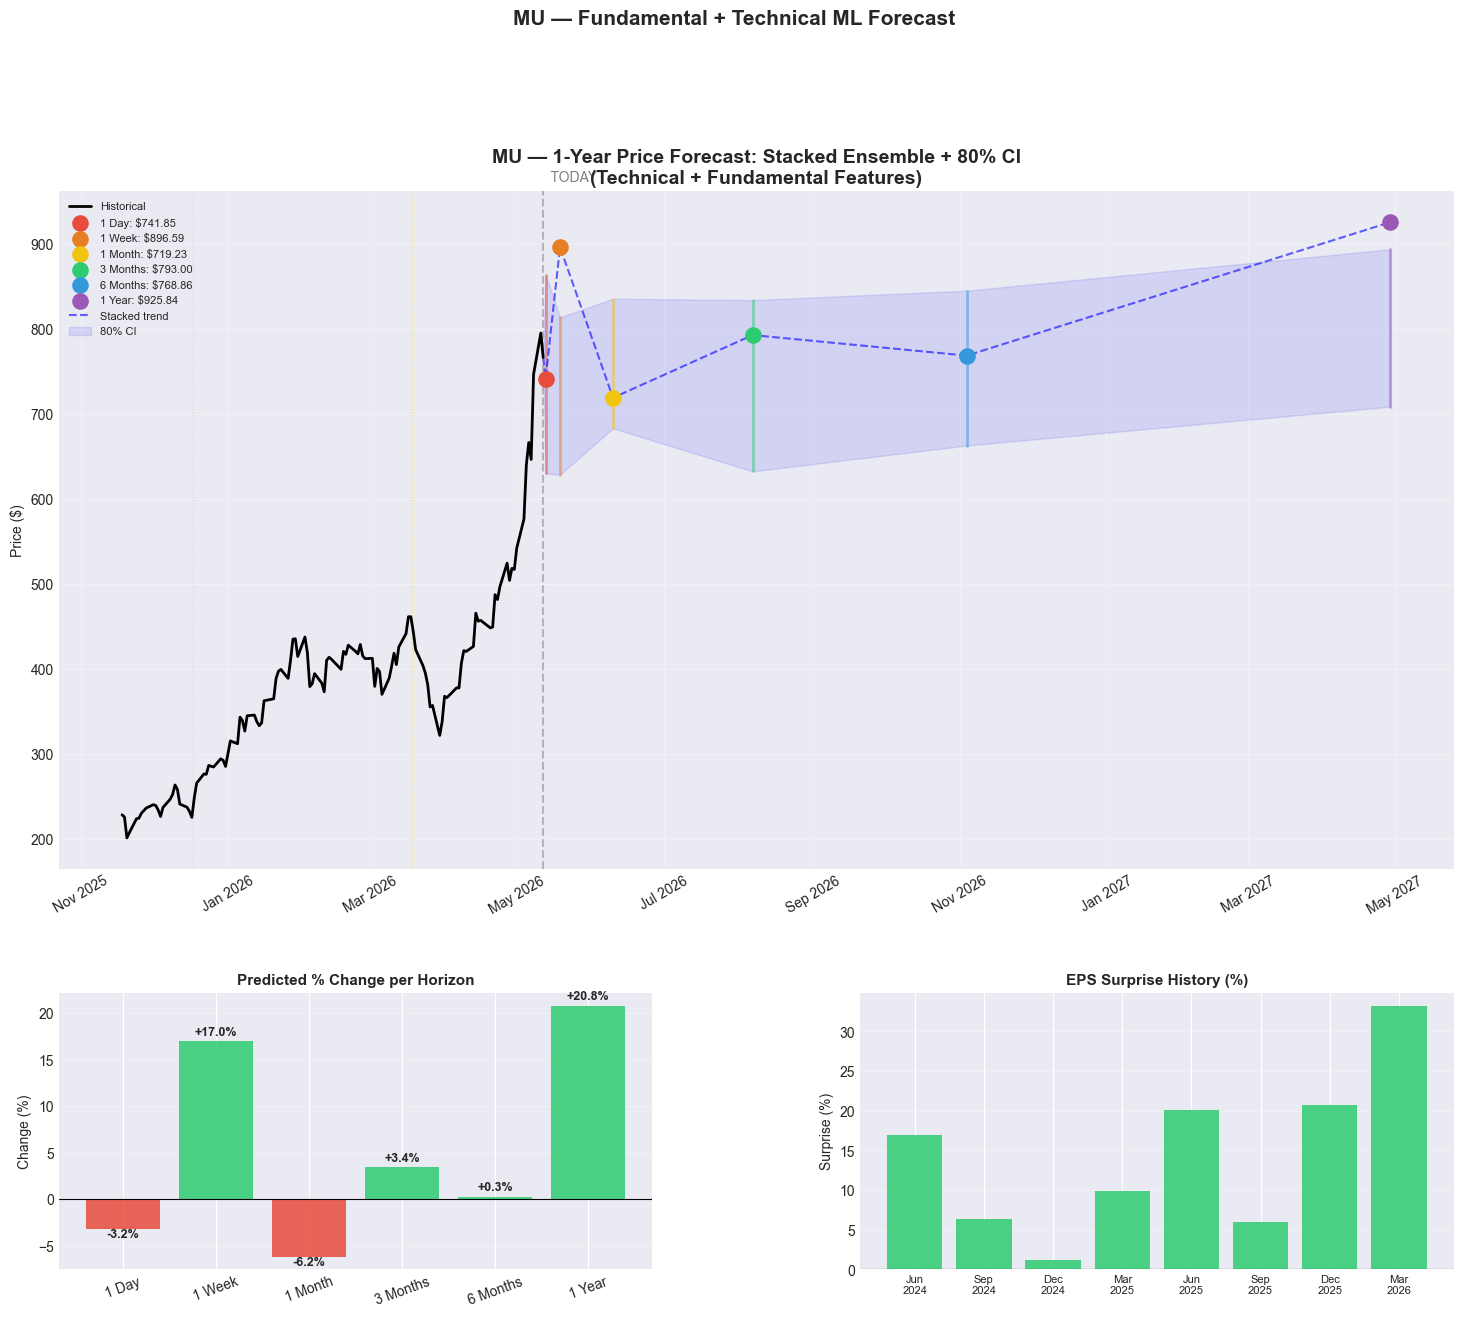

In [14]:
# ── Visualization ─────────────────────────────────────────────────────────────
pred_points  = {h: pd.bdate_range(start=last_date + timedelta(days=1), periods=h)[-1] for h in HORIZONS if h in results}
stacked_vals = [results[h]['Stacked'] for h in HORIZONS if h in results]
q10_vals     = [results[h]['Q10']     for h in HORIZONS if h in results]
q90_vals     = [results[h]['Q90']     for h in HORIZONS if h in results]
dates_plot   = [pred_points[h]        for h in HORIZONS if h in results]

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
ax_main = fig.add_subplot(gs[0:2, :])
ax_pct  = fig.add_subplot(gs[2, 0])
ax_earn = fig.add_subplot(gs[2, 1])

# ── Main: historical + prediction points ──────────────────────────────────────
hist = df['Close'].iloc[-120:]
ax_main.plot(hist.index, hist, color='black', linewidth=2, label='Historical', zorder=5)

colors_h = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']
for i, h in enumerate([h for h in HORIZONS if h in results]):
    ax_main.scatter(pred_points[h], results[h]['Stacked'],
                    color=colors_h[i], s=120, zorder=7,
                    label=f'{horizon_labels[h]}: ${results[h]["Stacked"]:.2f}')
    ax_main.plot([pred_points[h], pred_points[h]], [results[h]['Q10'], results[h]['Q90']],
                  color=colors_h[i], linewidth=2, alpha=0.5)

# Connect stacked points dengan garis
all_dates  = [last_date] + dates_plot
all_prices = [last_close] + stacked_vals
ax_main.plot(all_dates, all_prices, color='blue', linewidth=1.5, linestyle='--', alpha=0.6, label='Stacked trend')
ax_main.fill_between(all_dates, [last_close]+q10_vals, [last_close]+q90_vals, alpha=0.10, color='blue', label='80% CI')

ax_main.axvline(x=last_date, color='gray', linestyle='--', alpha=0.5)
ax_main.text(last_date, 1.01, '  TODAY', color='gray', fontsize=10,
             transform=ax_main.get_xaxis_transform(), va='bottom')

# Earnings event lines
if len(past_earnings) > 0:
    for ed in past_earnings:
        if ed >= hist.index[0]:
            ax_main.axvline(x=ed, color='gold', linewidth=0.8, alpha=0.6, linestyle=':')

ax_main.set_title(f'{TICKER} — 1-Year Price Forecast: Stacked Ensemble + 80% CI\n(Technical + Fundamental Features)', fontsize=14, fontweight='bold')
ax_main.set_ylabel('Price ($)')
ax_main.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax_main.grid(True, alpha=0.3)
ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_main.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax_main.xaxis.get_majorticklabels(), rotation=30)

# ── % Change per horizon ──────────────────────────────────────────────────────
valid_horizons = [h for h in HORIZONS if h in results]
pct_changes    = [(results[h]['Stacked'] / last_close - 1) * 100 for h in valid_horizons]
bar_colors     = ['#2ecc71' if p >= 0 else '#e74c3c' for p in pct_changes]
bars = ax_pct.bar([horizon_labels[h] for h in valid_horizons], pct_changes, color=bar_colors, alpha=0.85)
for bar, val in zip(bars, pct_changes):
    sign = '+' if val >= 0 else ''
    ax_pct.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if val >= 0 else -1.2),
                f'{sign}{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_pct.axhline(0, color='black', linewidth=0.8)
ax_pct.set_title('Predicted % Change per Horizon', fontsize=11, fontweight='bold')
ax_pct.set_ylabel('Change (%)')
ax_pct.grid(True, alpha=0.3, axis='y')
plt.setp(ax_pct.xaxis.get_majorticklabels(), rotation=20)

# ── EPS Surprise history ──────────────────────────────────────────────────────
if not earn_df.empty and 'EPS_Surprise_Pct' in earn_df.columns:
    recent_earn = earn_df.dropna(subset=['EPS_Surprise_Pct']).tail(8)
    if not recent_earn.empty:
        colors_earn = ['#2ecc71' if v >= 0 else '#e74c3c' for v in recent_earn['EPS_Surprise_Pct']]
        ax_earn.bar(range(len(recent_earn)), recent_earn['EPS_Surprise_Pct'] * 100, color=colors_earn, alpha=0.85)
        ax_earn.set_xticks(range(len(recent_earn)))
        ax_earn.set_xticklabels([d.strftime('%b\n%Y') for d in recent_earn.index], fontsize=8)
        ax_earn.axhline(0, color='black', linewidth=0.8)
        ax_earn.set_title('EPS Surprise History (%)', fontsize=11, fontweight='bold')
        ax_earn.set_ylabel('Surprise (%)')
        ax_earn.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'{TICKER} — Fundamental + Technical ML Forecast', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
### Fundamental Features yang Digunakan

| Kategori | Fitur | Sumber |
|----------|-------|--------|
| **Valuation** | P/E, Forward P/E, P/B, P/S, EV/EBITDA, PEG | `yf.info` |
| **Profitability** | ROE, ROA, Gross/Operating/Net/EBITDA Margin | `quarterly_income_stmt` |
| **Growth** | Revenue YoY, EPS YoY, EPS QoQ | Dihitung dari quarterly |
| **Financial Health** | Debt/Equity, Current Ratio, Quick Ratio | `quarterly_balance_sheet` |
| **Cash Flow** | FCF, FCF Margin, Operating CF | `quarterly_cash_flow` |
| **Earnings Events** | Days to/from earnings, EPS Surprise Abs/Pct | `earnings_dates` |
| **Post-Earnings Drift** | Return 1d / 3d / 5d setelah earnings | Dihitung dari harga |
| **Sentiment Proxy** | Short Ratio, % Institutional, % Insider | `yf.info` |
| **Market Context** | Beta | `yf.info` |

### Catatan Metodologi
- **Forward-fill**: data kuartalan diisi konstan hingga rilis berikutnya
- **Static fundamentals**: nilai snapshot terbaru dari `yf.info` — tidak berubah sepanjang periode historis
- **Event window**: model tahu berapa hari sebelum/sesudah earnings — menangkap volatilitas periodik
- **Direct multi-step**: model terpisah per horizon (1, 5, 21, 63, 126, 252 hari) — tidak rekursif
- **Horizon panjang (252 hari)**: hasil lebih tepat dibaca sebagai tren arah, bukan harga tepat

> ⚠️ **Disclaimer**: Hanya untuk keperluan edukatif — **bukan saran keuangan**
